In [30]:
### TASK 1 — Data Loading & Exploration ###

In [31]:
import pandas as pd
df = pd.read_csv(r"C:\Users\ravis\Downloads\Housing.csv")  #loading the dataset
print("First 10 Rows:")   #Display of First 10 rows
df.head(10)

First 10 Rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [32]:
rows, cols = df.shape      #checking the number of rows and columns
print(f"\nNumber of Rows: {rows}")
print(f"Number of Columns: {cols}")



Number of Rows: 545
Number of Columns: 13


In [33]:
target_column = "price"        #Identify the target column
feature_columns = [col for col in df.columns if col != target_column]   #identify the feature column

print("\nTarget Column:")
print(target_column)

print("\nFeature Columns:")
print(feature_columns)


Target Column:
price

Feature Columns:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [34]:
print("\nMissing Values in Each Column:")     #checking if there are any missing values
print(df.isnull().sum())


Missing Values in Each Column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [35]:
### TASK 2 — Data Cleaning ###

In [36]:
duplicates = df.duplicated().sum()  #removing the duplicates if any 
print(f"\nDuplicate Rows Found: {duplicates}")

df = df.drop_duplicates()

print(f"Rows after removing duplicates: {df.shape[0]}")


Duplicate Rows Found: 0
Rows after removing duplicates: 545


In [37]:
categorical_cols = df.select_dtypes(include=['object']).columns    #converting categorical columns

print("\nCategorical Columns:")
print(categorical_cols)

df_encoded = pd.get_dummies(df,columns=categorical_cols,drop_first=True)    #one-hot encoding

print("\nDataset Shape After Encoding:")
print(df_encoded.shape)


Categorical Columns:
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

Dataset Shape After Encoding:
(545, 14)


In [38]:
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

print("\nFeature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

display(df_encoded.head(10))


Feature Matrix Shape: (545, 13)
Target Variable Shape: (545,)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False
5,10850000,7500,3,3,1,2,True,False,True,False,True,True,True,False
6,10150000,8580,4,3,4,2,True,False,False,False,True,True,True,False
7,10150000,16200,5,3,2,0,True,False,False,False,False,False,False,True
8,9870000,8100,4,1,2,2,True,True,True,False,True,True,False,False
9,9800000,5750,3,2,4,1,True,True,False,False,True,True,False,True


In [46]:
### TASK 3 — Model Building ###

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Split Data (80% Train, 20% Test)

X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)


# 2. Linear Regression Model

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

# Evaluation Metrics
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("\n----- Linear Regression -----")
print("MAE :", round(lr_mae, 2))
print("RMSE:", round(lr_rmse, 2))
print("R2 Score:", round(lr_r2, 4))


# 3. Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# Evaluation Metrics
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("\n----- Random Forest Regressor -----")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R2 Score:", round(rf_r2, 4))


# 4. Performance Comparison

print("\n----- Model Comparison -----")

comparison = {
    "Metric": ["MAE", "RMSE", "R2 Score"],
    "Linear Regression": [lr_mae, lr_rmse, lr_r2],
    "Random Forest": [rf_mae, rf_rmse, rf_r2]
}

import pandas as pd
comparison_df = pd.DataFrame(comparison)

display(comparison_df)

Training Set Shape: (436, 13)
Testing Set Shape: (109, 13)

----- Linear Regression -----
MAE : 970043.4
RMSE: 1324506.96
R2 Score: 0.6529

----- Random Forest Regressor -----
MAE : 1049865.9
RMSE: 1418191.21
R2 Score: 0.6021

----- Model Comparison -----


,Metric,Linear Regression,Random Forest
0,MAE,9.700434e+05,1.049866e+06
1,RMSE,1.324507e+06,1.418191e+06
2,R2 Score,6.529243e-01,6.020896e-01


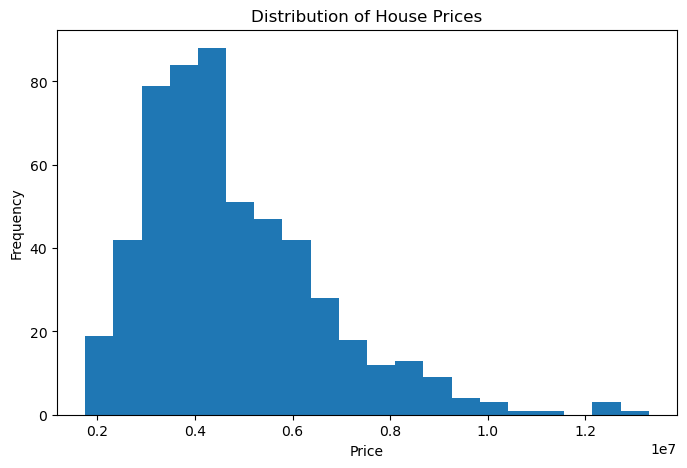

In [40]:
### TASK 4 — Visualization ###

#Histogram of house prices
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=20)

plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

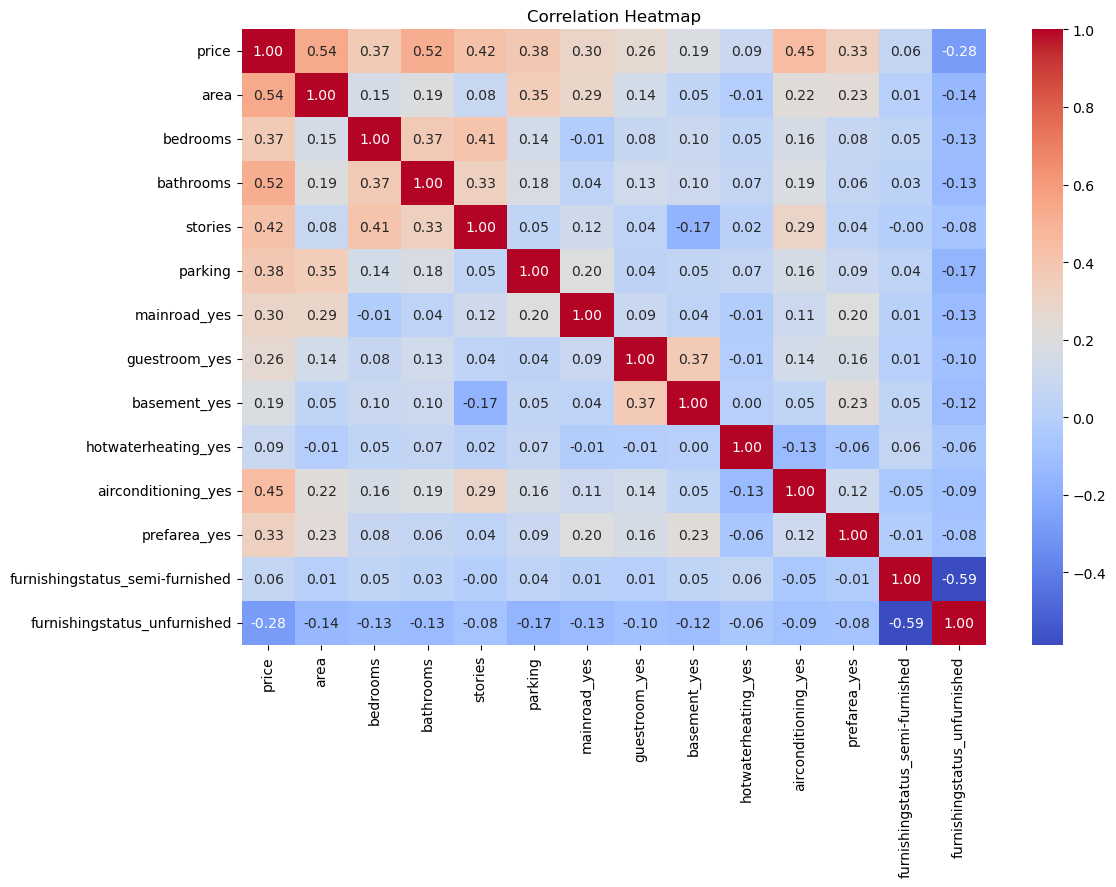

In [41]:
#Correlation heatmap showing which features relate most strongly to price

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

corr_matrix = df_encoded.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

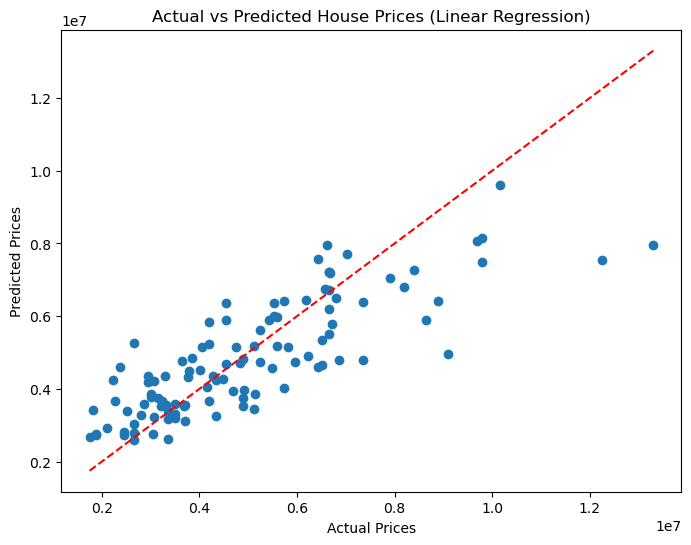

In [42]:
#Actual vs Predicted Prices

plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices (Linear Regression)")

# Reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

In [45]:
### TASK 5 — Insights & Summary ###

print("""
Insights & Summary

1. The most influential features for predicting house prices were area, bathrooms,
   stories, parking, and air conditioning.

2. The Linear Regression model achieved an R² Score of approximately 0.65,
   indicating that it explained about 65% of the variation in house prices.

3. A surprising observation was that Linear Regression performed better than
   Random Forest Regressor, suggesting that the dataset contains mostly linear
   relationships between features and price.

4. Real estate businesses should prioritize properties with larger living areas,
   more bathrooms, sufficient parking spaces, and modern facilities such as
   air conditioning to maximize property value and market appeal.
""")


Insights & Summary

1. The most influential features for predicting house prices were area, bathrooms,
   stories, parking, and air conditioning.

2. The Linear Regression model achieved an R² Score of approximately 0.65,
   indicating that it explained about 65% of the variation in house prices.

3. A surprising observation was that Linear Regression performed better than
   Random Forest Regressor, suggesting that the dataset contains mostly linear
   relationships between features and price.

4. Real estate businesses should prioritize properties with larger living areas,
   more bathrooms, sufficient parking spaces, and modern facilities such as
   air conditioning to maximize property value and market appeal.

